<a href="https://colab.research.google.com/github/tanishka021/ML_PROJECTS/blob/main/demo_project_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

In [ ]:
import os
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'iris' dataset.
Path to dataset files: /kaggle/input/iris


In [ ]:
import pandas as pd


In [ ]:
#df = pd.read_csv(os.path.join(path, "Iris.csv"))
df= pd.read_csv("Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.shape

(150, 6)

##STEP 1 - PREPROCESS , EDA , FEATURE SELECTION

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
df = df.iloc[:,1:]

In [ ]:
df.head()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Species_encoded
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

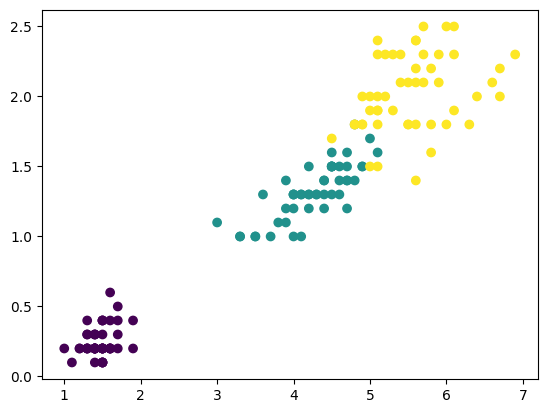

In [ ]:
plt.scatter(df['PetalLengthCm'],df['PetalWidthCm'],c=df['Species_encoded'])

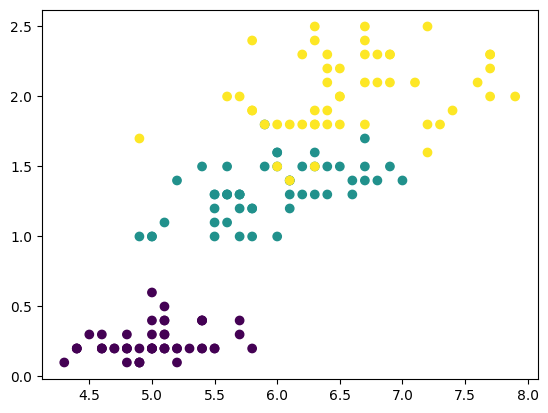

In [ ]:
plt.scatter(df["SepalLengthCm"],df['PetalWidthCm'],c=df['Species_encoded'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Species_encoded'] = le.fit_transform(df['Species'])


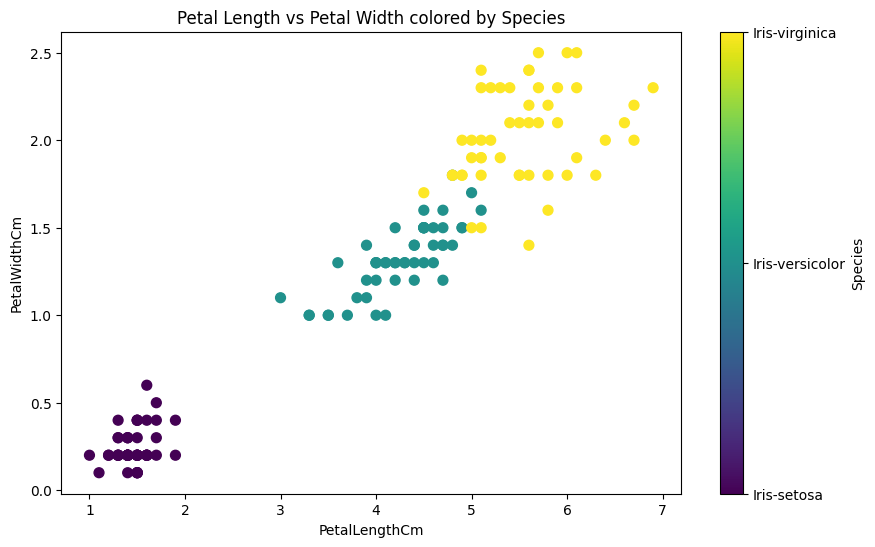

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['PetalLengthCm'], df['PetalWidthCm'], c=df['Species_encoded'], cmap='viridis', s=50)
plt.xlabel('PetalLengthCm')
plt.ylabel('PetalWidthCm')
plt.title('Petal Length vs Petal Width colored by Species')

# Create a legend based on the original species names
cbar = plt.colorbar(ticks=df['Species_encoded'].unique())
cbar.set_ticklabels(le.inverse_transform(df['Species_encoded'].unique()))
cbar.set_label('Species')

plt.show()


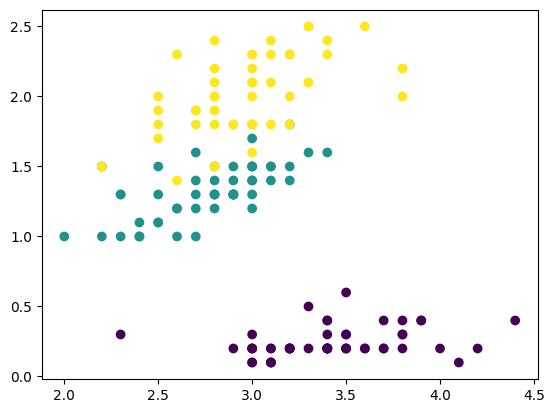

In [ ]:
plt.scatter(df["SepalWidthCm"],df['PetalWidthCm'],c=df['Species_encoded'])

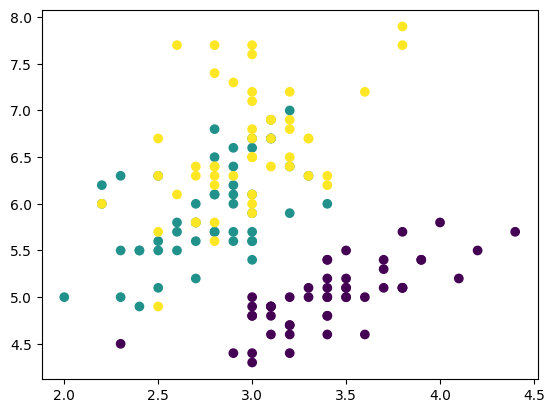

In [ ]:
plt.scatter(df["SepalWidthCm"],df['SepalLengthCm'],c=df['Species_encoded'])

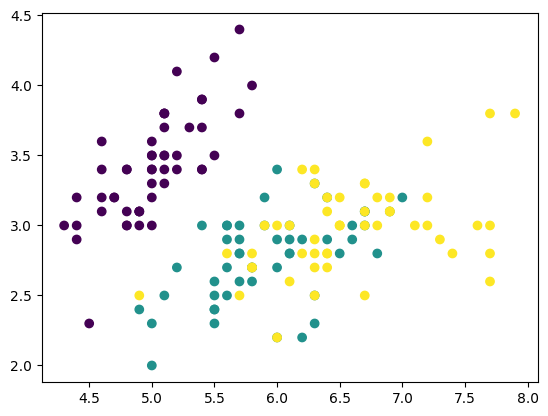

In [ ]:
plt.scatter(df["SepalLengthCm"],df['SepalWidthCm'],c=df['Species_encoded'])

##FEATURE SELECTION

In [ ]:
x= df.iloc[:,:4]
y=df.iloc[:,-1]

In [ ]:
y

,Species_encoded
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.1)

In [ ]:
from sklearn.linear_model import LogisticRegression

##TRAIN MODEL

In [ ]:
clf = LogisticRegression()

In [ ]:
clf.fit(x_train,y_train)

LogisticRegression()

NameError: name 'x_train' is not defined

##MODEL EVALUATION

In [ ]:
y_pred = clf.predict(x_test)

In [ ]:
y_test

,Species_encoded
106,2
43,0
59,1
65,1
83,1
129,2
142,2
130,2
92,1
8,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.8666666666666667